In [1]:
import sys
import os

# add src folder to path
sys.path.append(os.path.abspath("../src")) 

from imports import * 

In [ ]:
''' 
This notebook performs volatility forecasting using past observations:
    For each timeseries (prices, volatility):
        Historical data is split into training (2014-2023) and test (2024) periods (done)
        An N-BEATS neural network is trained on the timeseries
        Model results scored and recored
        Forecast is plotted against true observations

'''

In [ ]:
# load prices.csv
prices = pd.read_csv("../data/prices.csv", index_col=0, parse_dates=True) 

print(prices.info())
prices

In [2]:
# load returns.csv
returns = pd.read_csv("../data/returns.csv", index_col=0, parse_dates=True) 

print(returns.info())
returns

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2734 entries, 2014-01-02 to 2024-06-28
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EURUSD=X  2734 non-null   float64
 1   CAD=X     2734 non-null   float64
dtypes: float64(2)
memory usage: 64.1 KB
None


,EURUSD=X,CAD=X
Date,,
2014-01-02,0.237312,0.158325
2014-01-03,0.231106,-0.727065
2014-01-06,-0.361792,-0.516652
2014-01-07,0.285965,0.264468
2014-01-08,1.051503,-0.114382
...,...,...
2024-06-24,0.121303,-0.174209
2024-06-25,-0.316753,0.420722
2024-06-26,0.023427,-0.215266


In [3]:
# choose which data to use for modeling
# forecast_name = 'prices'
# data = prices.copy()

# forecast_name = 'returns'
# data=returns.copy() 

forecast_name = 'returns_sq'
data=returns.copy()**2

In [4]:
# list of ticker names
tickers = data.columns

In [5]:
# Split data into train, validation, and test sets
train_split = '2022-01-01'
val_split = '2023-01-01' 
train = data.loc[:'2021-12-31']
val = data.loc[train_split:'2022-12-31']
test = data.loc[val_split:]

# check
print(train.shape, val.shape, test.shape)
print(train.index.min(), train.index.max())
print(val.index.min(), val.index.max())
print(test.index.min(), test.index.max())

print("Train")
print(train)
print("Validation")
print(val)
print("Test")
print(test)


(2084, 2) (260, 2) (390, 2)
2014-01-02 00:00:00 2021-12-31 00:00:00
2022-01-03 00:00:00 2022-12-30 00:00:00
2023-01-02 00:00:00 2024-06-28 00:00:00
Train
            EURUSD=X     CAD=X
Date                          
2014-01-02  0.056317  0.025067
2014-01-03  0.053410  0.528623
2014-01-06  0.130894  0.266929
2014-01-07  0.081776  0.069943
2014-01-08  1.105658  0.013083
...              ...       ...
2021-12-27  0.005960  0.000738
2021-12-28  0.044397  0.002599
2021-12-29  0.041342  0.018129
2021-12-30  0.056290  0.160809
2021-12-31  0.089305  0.095589

[2084 rows x 2 columns]
Validation
            EURUSD=X     CAD=X
Date                          
2022-01-03  0.451144  0.182882
2022-01-04  0.533952  0.392059
2022-01-05  0.135284  0.027139
2022-01-06  0.192225  0.070083
2022-01-07  0.054908  0.021569
...              ...       ...
2022-12-26  0.119291  0.369734
2022-12-27  0.057901  0.066853
2022-12-28  0.055717  0.000825
2022-12-29  0.302609  0.005537
2022-12-30  0.121483  0.087837

[26

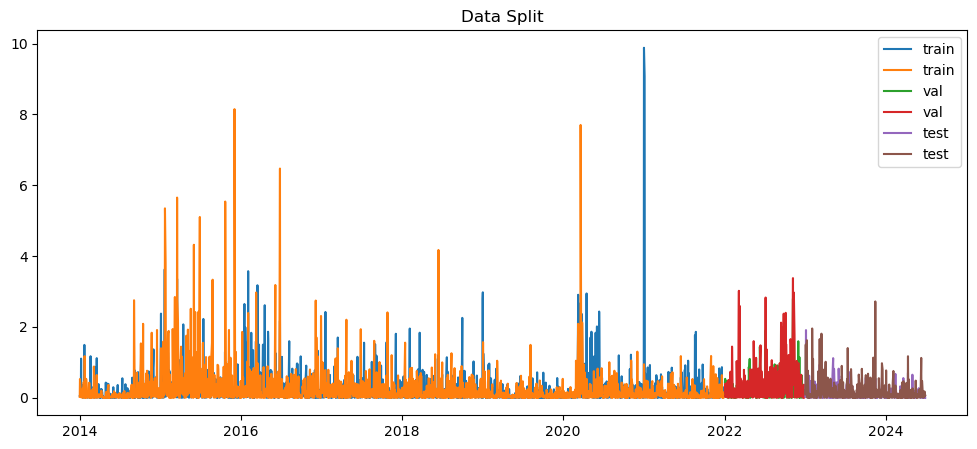

In [6]:
plt.figure(figsize=(12, 5))

plt.plot(train.index, train, label="train")
plt.plot(val.index, val, label="val")
plt.plot(test.index, test, label="test")

plt.title("Data Split")
plt.legend()
plt.show()

In [7]:
data.reset_index(inplace=True)
train.reset_index(inplace=True)
val.reset_index(inplace=True)
test.reset_index(inplace=True)

In [8]:
data

,Date,EURUSD=X,CAD=X
0,2014-01-02,0.056317,0.025067
1,2014-01-03,0.053410,0.528623
2,2014-01-06,0.130894,0.266929
3,2014-01-07,0.081776,0.069943
4,2014-01-08,1.105658,0.013083
...,...,...,...
2729,2024-06-24,0.014714,0.030349
2730,2024-06-25,0.100333,0.177007
2731,2024-06-26,0.000549,0.046340
2732,2024-06-27,0.100930,0.075927


In [9]:
# to do: avoid 0 filling somehow
series_ts = TimeSeries.from_dataframe(
    data,
    time_col='Date',
    value_cols=list(data.columns)[1:],
    # fill_missing_dates=True,
    fillna_value=0.0,
    freq='B'
).astype(np.float32)

train_ts = TimeSeries.from_dataframe(
    train, 
    time_col='Date', 
    value_cols=list(data.columns)[1:], 
    # fill_missing_dates=True, 
    fillna_value=0.0,
    freq='B'
    )

val_ts = TimeSeries.from_dataframe(
    val, 
    time_col='Date', 
    value_cols=list(data.columns)[1:], 
    # fill_missing_dates=True, 
    fillna_value=0.0,
    freq='B'
    )
    
test_ts = TimeSeries.from_dataframe(
    test, 
    time_col='Date', 
    value_cols=list(data.columns)[1:], 
    # fill_missing_dates=True, 
    fillna_value=0.0,
    freq='B'
    )

In [10]:
train_ts

,EURUSD=X,CAD=X
Date,,
2014-01-02,0.056317,0.025067
2014-01-03,0.053410,0.528623
2014-01-06,0.130894,0.266929
2014-01-07,0.081776,0.069943
2014-01-08,1.105658,0.013083
...,...,...
2021-12-27,0.005960,0.000738
2021-12-28,0.044397,0.002599
2021-12-29,0.041342,0.018129


In [11]:
print(type(series_ts))

<class 'darts.timeseries.TimeSeries'>


In [12]:
# check null values
null_count_df = series_ts.to_dataframe()
print(null_count_df)
print(null_count_df.isna().sum())

# print where it is null if any
null_count_df[null_count_df.isna().any(axis=1)] 

            EURUSD=X     CAD=X
Date                          
2014-01-02  0.056317  0.025067
2014-01-03  0.053410  0.528623
2014-01-06  0.130894  0.266929
2014-01-07  0.081776  0.069943
2014-01-08  1.105658  0.013083
...              ...       ...
2024-06-24  0.014714  0.030349
2024-06-25  0.100333  0.177007
2024-06-26  0.000549  0.046340
2024-06-27  0.100930  0.075927
2024-06-28  0.001440  0.070529

[2737 rows x 2 columns]
EURUSD=X    0
CAD=X       0
dtype: int64


,EURUSD=X,CAD=X
Date,,


In [13]:
# Scaler
scaler = Scaler(MinMaxScaler(feature_range=(-1,1))) 

train_scaled = scaler.fit_transform(train_ts)
val_scaled = scaler.transform(val_ts)
test_scaled = scaler.transform(test_ts)
series_scaled = scaler.transform(series_ts)

In [15]:
# Define nbeats model
seed = 42
nbeats_name = "nbeats"

# parameters
params = {
    'lags': 20,
    'steps': 1,
    'stacks': 2,
    'blocks': 2,
    'layers': 2,
    'l_widths': 64,
    'epochs': 10,
    'b_size': 32
}
start = time.time()
model_nbeats = NBEATSModel(
    input_chunk_length=params['lags'],       # use last 20 observations
    output_chunk_length=params['steps'],       # forecast 1 step ahead
    generic_architecture=True,
    num_stacks=params['stacks'],
    num_blocks=params['blocks'],
    num_layers=params['layers'],
    layer_widths=params['l_widths'],
    n_epochs=params['epochs'], 
    batch_size=params['b_size'],
    random_state=seed,
    model_name=nbeats_name,
    save_checkpoints=True,
    force_reset=True,
)

# fit model
history = model_nbeats.fit(
    train_scaled, 
    val_series=val_scaled,
    verbose=True)
end = time.time()

time_spent = end - start

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 30.7 K | train
-------------------------------------------------------------
30.2 K    Trainable params
565       Non-trainable params
30.7 K    Total params
0.123     Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


In [16]:
mins, secs = time_spent // 60, time_spent % 60 
print(f'Time elapsed: {int(mins)}m {secs}s')

Time elapsed: 0m 19.522064447402954s


In [17]:
model_nbeats = NBEATSModel.load_from_checkpoint(model_name=nbeats_name, best=True)

In [18]:
one_pred = model_nbeats.predict(n=1, series=train_scaled)
print(one_pred) 

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

            EURUSD=X     CAD=X
Date                          
2022-01-03 -0.973812 -0.933759

shape: (1, 2, 1), freq: B, size: 16.00 B


In [19]:
print(len(train), len(val), len(test))

2084 260 390


In [20]:
print(series_scaled.start_time(), series_scaled.end_time())
print(test['Date'].iloc[0])

2014-01-02 00:00:00 2024-06-28 00:00:00
2023-01-02 00:00:00


In [21]:
# historical_forecasts rolls forward through the test period
pred_scaled = model_nbeats.historical_forecasts(
    series=series_scaled,
    start=test['Date'].iloc[0],
    forecast_horizon=1,
    stride=1,
    last_points_only=True,
    retrain=False,
    verbose=True
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

In [22]:
pred_ts = scaler.inverse_transform(pred_scaled) 
print(type(pred_scaled))
print(type(pred_ts))
print(type(test_ts))

print(pred_scaled)
print(pred_ts)
print(test_ts)

<class 'darts.timeseries.TimeSeries'>
<class 'darts.timeseries.TimeSeries'>
<class 'darts.timeseries.TimeSeries'>
            EURUSD=X     CAD=X
Date                          
2023-01-02 -0.979857 -0.927861
2023-01-03 -0.973831 -0.931011
2023-01-04 -0.986193 -0.937481
2023-01-05 -0.969581 -0.903507
2023-01-06 -0.943292 -0.915503
...              ...       ...
2024-06-24 -0.993239 -0.935822
2024-06-25 -0.995757 -0.935840
2024-06-26 -0.989555 -0.926877
2024-06-27 -0.988164 -0.936113
2024-06-28 -0.988416 -0.930475

shape: (390, 2, 1), freq: B, size: 6.09 KB
            EURUSD=X     CAD=X
Date                          
2023-01-02  0.099514  0.293904
2023-01-03  0.129284  0.281069
2023-01-04  0.068213  0.254710
2023-01-05  0.150279  0.393124
2023-01-06  0.280158  0.344251
...              ...       ...
2024-06-24  0.033401  0.261471
2024-06-25  0.020963  0.261398
2024-06-26  0.051604  0.297913
2024-06-27  0.058475  0.260284
2024-06-28  0.057229  0.283256

shape: (390, 2, 1), freq: B, size: 

In [23]:
# evaluate model
scores = {}
for ticker in tickers:   
    rootmeansquarederr = rmse(test_ts[ticker], pred_ts[ticker])
    sMAPE = smape(test_ts[ticker], pred_ts[ticker])

    scores[ticker] = {'RMSE': rootmeansquarederr, 'sMAPE': sMAPE} 

scores

{'EURUSD=X': {'RMSE': np.float64(0.20400907238354823),
  'sMAPE': np.float64(121.63852087866753)},
 'CAD=X': {'RMSE': np.float64(0.3347900323991541),
  'sMAPE': np.float64(120.46644701960402)}}

In [24]:
# scores to data
scores_df = pd.DataFrame.from_dict(scores, orient='index') 

# save scores
scores_df.to_csv(f'../results/tables/nbeats_{forecast_name}_scores.csv')
scores_df

,RMSE,sMAPE
EURUSD=X,0.204009,121.638521
CAD=X,0.334790,120.466447


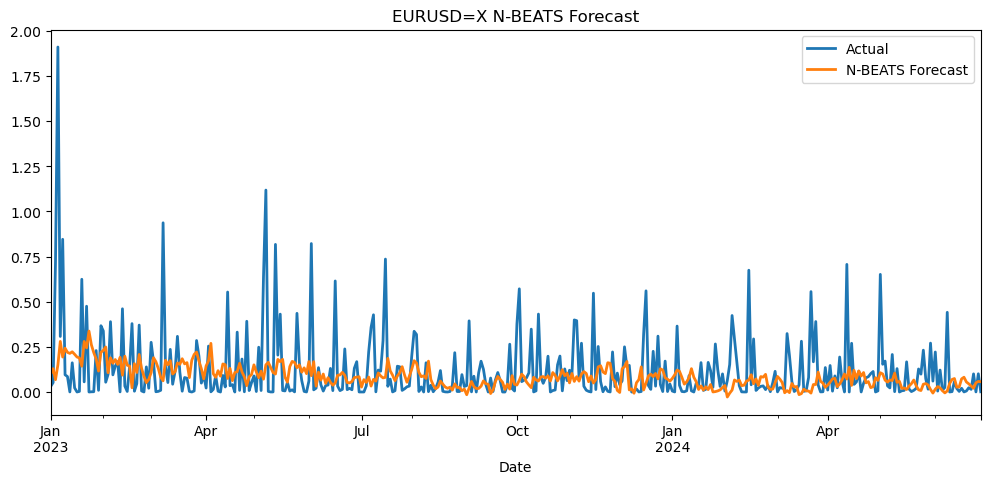

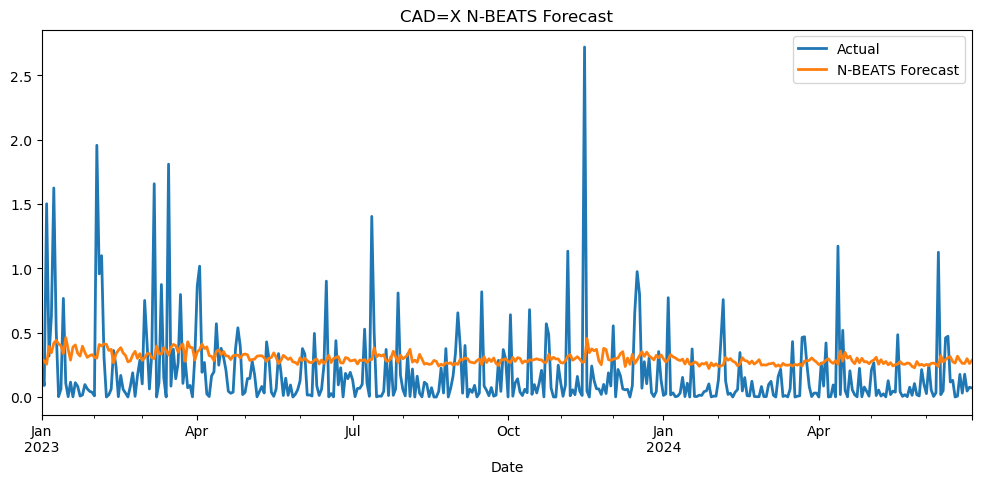

In [25]:
for ticker in tickers:
    plt.figure(figsize=(12, 5))
    
    title = f"{ticker} N-BEATS Forecast"
    test_ts[ticker].plot(label="Actual")
    pred_ts[ticker].plot(label="N-BEATS Forecast")
    plt.title(title)

    # save plot 
    plt.savefig(f"../results/figures/{title}.png", dpi=300, bbox_inches="tight")

    plt.legend()
    plt.show()

In [26]:
preds = pred_ts.to_dataframe()

# actual = test.copy() 
# actual.set_index('Date', inplace=True)

# results = pd.merge(actual, preds, left_index=True, right_index=True, how='inner')
results = preds.copy()

new_columns = []
# for ticker in tickers:
#     new_columns.append(ticker)
for ticker in tickers:
    new_columns.append(f'{ticker}_forecast')

results.columns = new_columns

print(results.info())
results

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 390 entries, 2023-01-02 to 2024-06-28
Freq: B
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EURUSD=X_forecast  390 non-null    float64
 1   CAD=X_forecast     390 non-null    float64
dtypes: float64(2)
memory usage: 9.1 KB
None


,EURUSD=X_forecast,CAD=X_forecast
Date,,
2023-01-02,0.099514,0.293904
2023-01-03,0.129284,0.281069
2023-01-04,0.068213,0.254710
2023-01-05,0.150279,0.393124
2023-01-06,0.280158,0.344251
...,...,...
2024-06-24,0.033401,0.261471
2024-06-25,0.020963,0.261398
2024-06-26,0.051604,0.297913


In [27]:
# save results
results.to_csv(f"../results/forecasts/nbeats_{forecast_name}_forecasts.csv")

# Tuning


In [ ]:
# # Define nbeats model
# seed = 42
# nbeats_name = "nbeats"

# # parameters
# params = {
#     'lags': [5, 10, 20, 40, 60],
#     'steps': [1, 30, 60],
#     'stacks': [2, 10],
#     'blocks': [2, 4],
#     'layers': [2, 4],
#     'l_widths': [64, 256],
#     'epochs': 200,
#     'b_size': 32
# }

# model_nbeats = NBEATSModel(
#     input_chunk_length=params['lags'],       # use last 20 observations
#     output_chunk_length=params['steps'],       # forecast 1 step ahead
#     generic_architecture=True,
#     num_stacks=params['stacks'],
#     num_blocks=params['blocks'],
#     num_layers=params['layers'],
#     layer_widths=params['l_widths'],
#     n_epochs=params['epochs'], 
#     batch_size=params['b_size'],
#     random_state=seed,
#     model_name=nbeats_name,
#     save_checkpoints=True,
#     force_reset=True,
# )

# # fit model
# history = model_nbeats.fit(
#     train_scaled, 
#     val_series=val_scaled,
#     verbose=True)